# 1. Pie charts

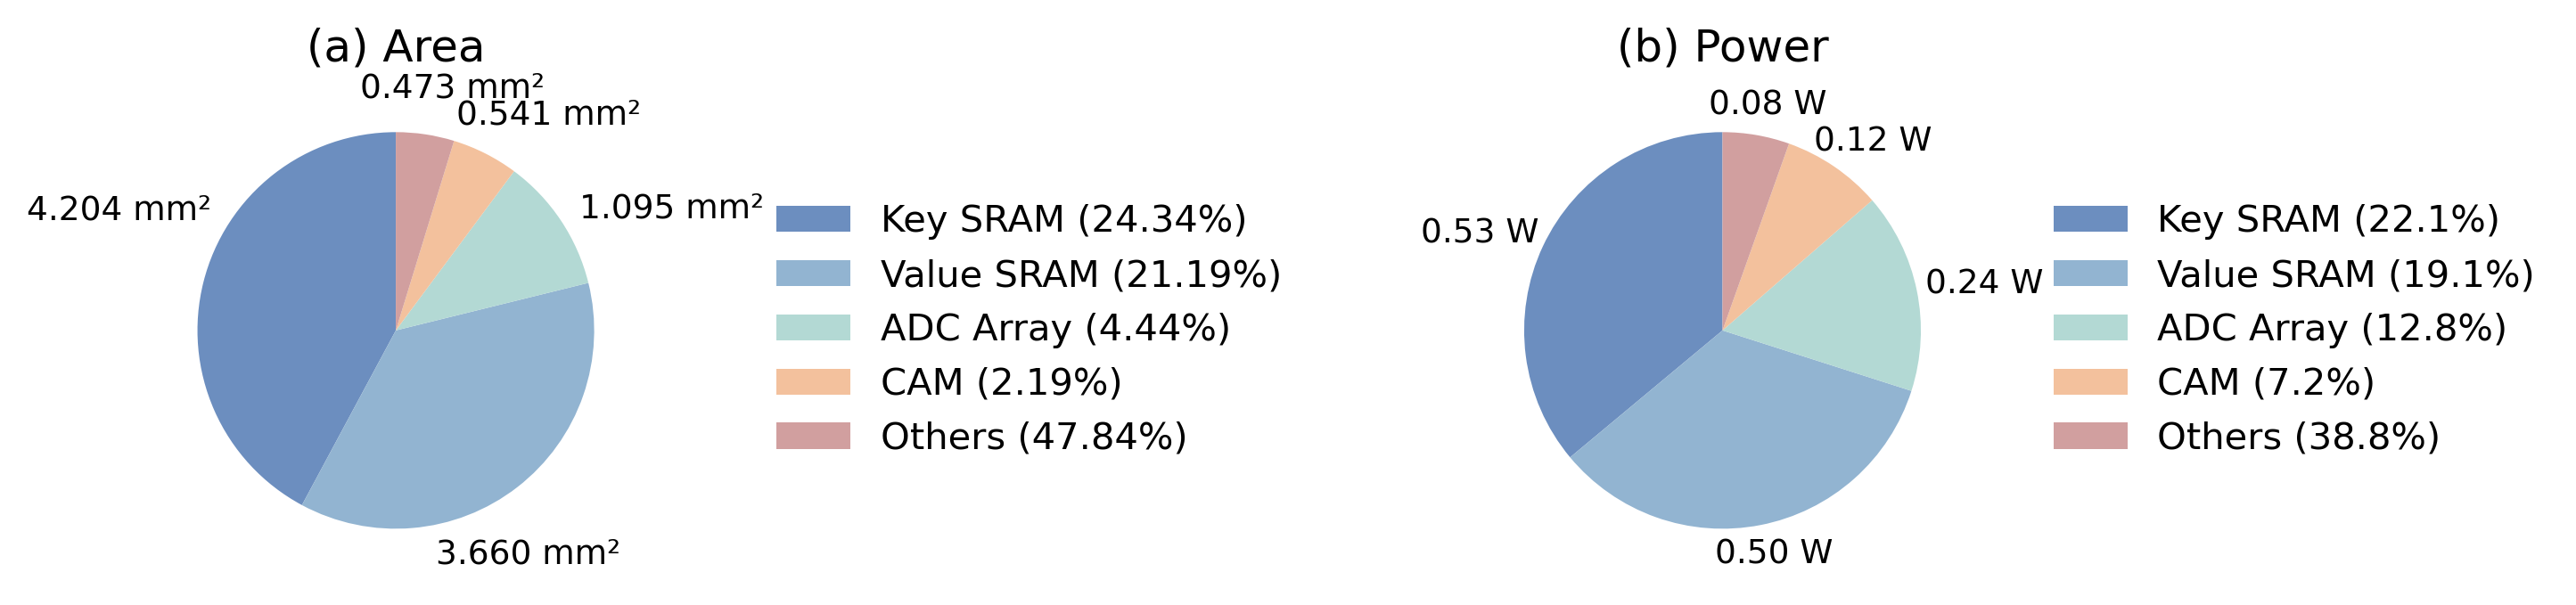

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Area and Power
area_values = [4.204, 3.660, 1.095, 0.541, 0.473]  # mm²
power_values = [0.53, 0.50, 0.24, 0.12, 0.08]  # W
labels = ['Key SRAM', 'Value SRAM', 'ADC Array', 'CAM', 'Others']
area_percentages = [24.34, 21.19, 4.44, 2.19, 47.84]
power_percentages = [22.1, 19.1, 12.8, 7.2, 38.8]

# Define muted color palette
colors = ['#6c8ebf', '#92b4d1', '#b3d9d4', '#f3c19d', '#d19f9f']  # Muted tones

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# Plot for Area
wedges_area, texts_area, autotexts_area = axs[0].pie(
    area_values,
    colors=colors,
    startangle=90,
    autopct='',  # No percentages
    textprops={'fontsize': 10, 'color': 'black', 'weight': 'bold'}
)

# Add area values to the pie chart
for wedge, value in zip(wedges_area, area_values):
    angle = (wedge.theta2 - wedge.theta1) / 2.5 + wedge.theta1
    x = 1.6 * np.cos(np.deg2rad(angle))  # Position slightly outward
    y = 1.24 * np.sin(np.deg2rad(angle))
    axs[0].text(x, y, f'{value:.3f} mm²', ha='center', va='center', fontsize=9)

# Title and Legend for Area
axs[0].set_title('(a) Area', fontsize=12)
axs[0].legend(
    wedges_area,
    [f'{labels[i]} ({area_percentages[i]}%)' for i in range(len(labels))],
    loc='center left',
    bbox_to_anchor=(1.2, 0.5),  # Legend to the right of the area chart
    fontsize=10,
    frameon=False
)

# Plot for Power
wedges_power, texts_power, autotexts_power = axs[1].pie(
    power_values,
    colors=colors,
    startangle=90,
    autopct='',  # No percentages
    textprops={'fontsize': 10, 'color': 'black', 'weight': 'bold'}
)

# Add power values to the pie chart
for wedge, value in zip(wedges_power, power_values):
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = 1.35 * np.cos(np.deg2rad(angle))  # Position slightly outward
    y = 1.15 * np.sin(np.deg2rad(angle))
    axs[1].text(x, y, f'{value:.2f} W', ha='center', va='center', fontsize=9)

# Title and Legend for Power
axs[1].set_title('(b) Power', fontsize=12)
axs[1].legend(
    wedges_power,
    [f'{labels[i]} ({power_percentages[i]}%)' for i in range(len(labels))],
    loc='center left',
    bbox_to_anchor=(1.1, 0.5),  # Legend to the right of the power chart
    fontsize=10,
    frameon=False
)

# Adjust layout
plt.tight_layout()
plt.show()


# 2.Speed up bars

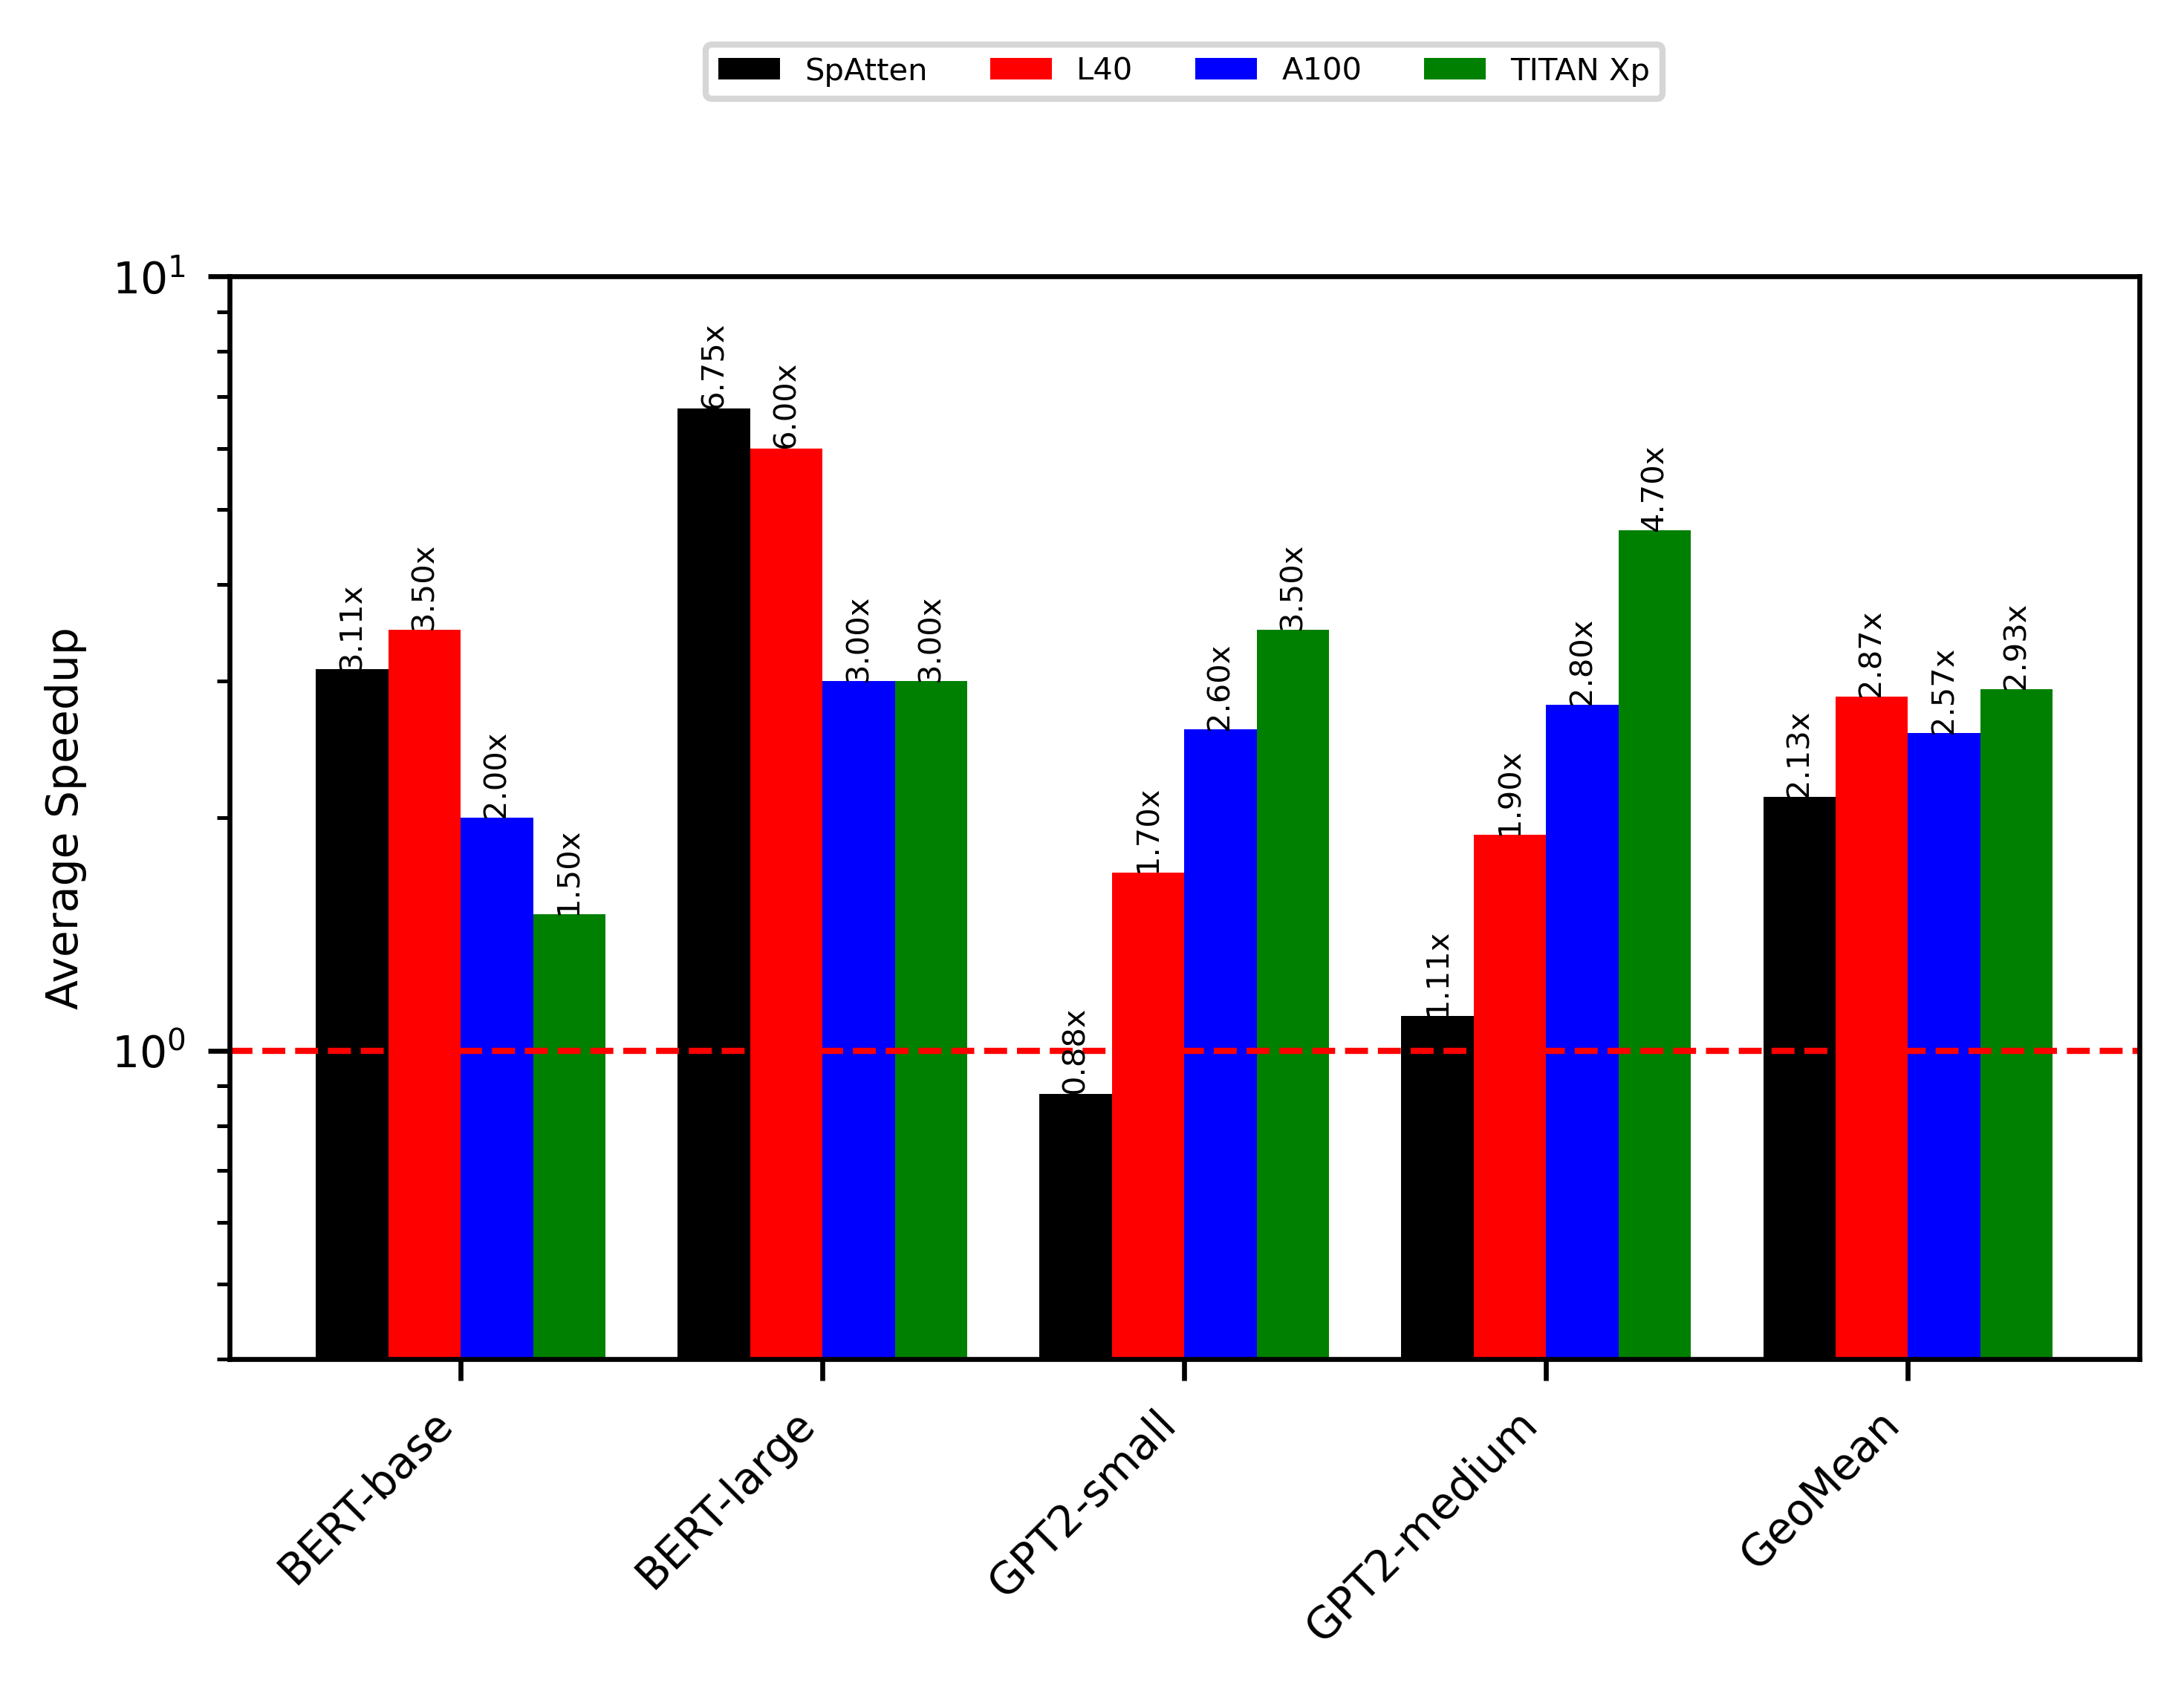

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gmean

# Data
model_types = ['BERT-base', 'BERT-large', 'GPT2-small', 'GPT2-medium']
devices = ['SpAtten', 'L40', 'A100', 'TITAN Xp']
colors = ['#000000', '#FF0000', '#0000FF', '#008000']
# Speedups for each device
speedups = {
    'SpAtten': [3.11, 6.75, 0.88, 1.11],
    'L40': [3.5, 6.0, 1.7, 1.9],
    'A100': [2.0, 3.0, 2.6, 2.8],
    'TITAN Xp': [1.5, 3.0, 3.5, 4.7]
}

# Calculate GeoMean for each device
geo_means = {device: gmean(values) for device, values in speedups.items()}

# Set up the plot
fig, ax = plt.subplots(figsize=(5, 4), dpi=600)

# Bar width and positions
width = 0.2
x = np.arange(len(model_types) + 1)  # +1 for the GeoMean bar

# Create bars for each device
for i, device in enumerate(devices):
    offset = width * (i - len(devices)/2 + 0.5)
    # Add bars for individual models
    bars = ax.bar(x[:-1] + offset, speedups[device], width, label=device, color=colors[i])
    
    # Add GeoMean bar
    geo_bar = ax.bar(x[-1] + offset, geo_means[device], width, color=colors[i])
    
    # Add value labels on top of bars
    for bar, value in zip(bars, speedups[device]):
        ax.text(bar.get_x() + bar.get_width()/2., value, f'{value:.2f}x',
                ha='center', va='bottom', fontsize=5, rotation=90)
    # Add GeoMean value label
    ax.text(x[-1] + offset, geo_means[device], f'{geo_means[device]:.2f}x',
            ha='center', va='bottom', fontsize=5, rotation=90)

# Customize the plot
ax.set_ylabel('Average Speedup', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(model_types + ['GeoMean'], rotation=45, ha='right', fontsize=7)
ax.tick_params(axis='y', labelsize=7)

# Add horizontal line at y=1
ax.axhline(y=1, color='red', linestyle='--', linewidth=1)

# Set y-axis to log scale
ax.set_yscale('log')
ax.set_ylim(0.4, 10)

# Add legend
ax.legend(fontsize=5, ncol=4, bbox_to_anchor=(0.5, 1.15), loc='lower center')

# Adjust layout
plt.tight_layout()

plt.show()


# 3.

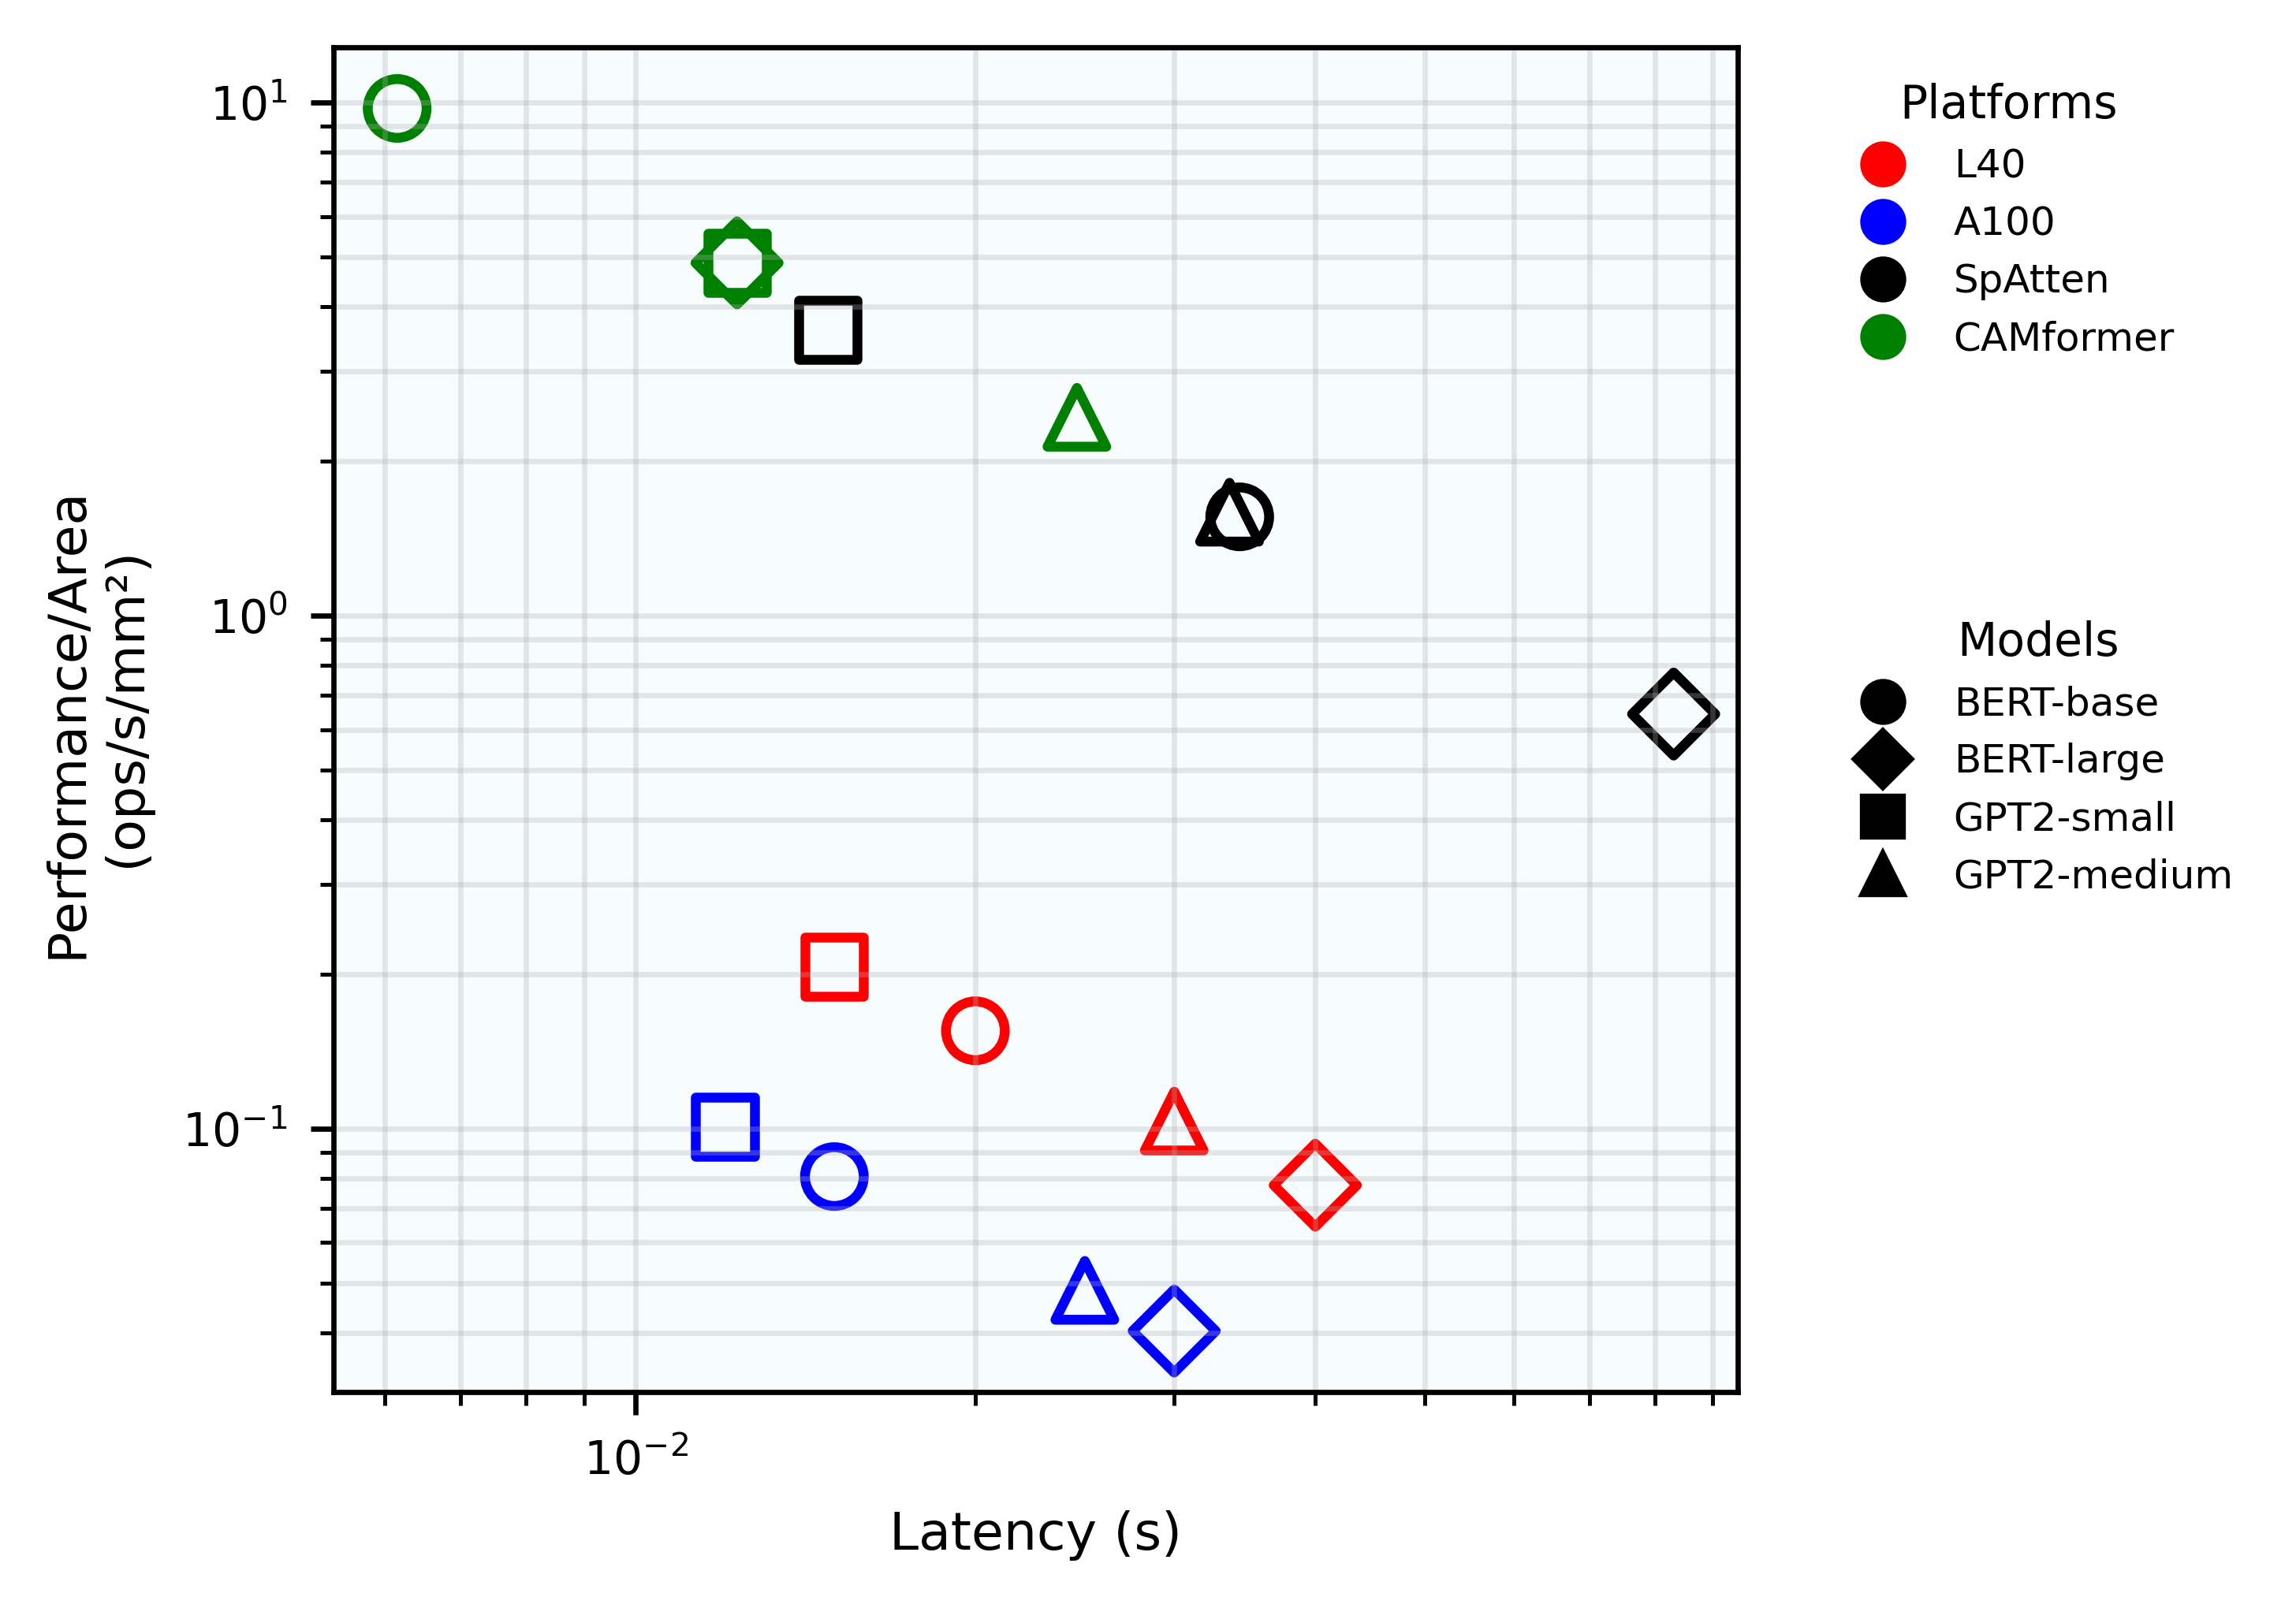

In [65]:
import matplotlib.pyplot as plt

# Define the function for Performance/Area
def calc_perf_area(latency, area):
    return 1 / (latency * area)

# Data points
platforms = {
    'L40': {
        'color': 'red',
        'area': 322,
        'BERT-base': (0.020, calc_perf_area(0.020, 322)),
        'BERT-large': (0.040, calc_perf_area(0.040, 322)),
        'GPT2-small': (0.015, calc_perf_area(0.015, 322)),
        'GPT2-medium': (0.030, calc_perf_area(0.030, 322)),
    },
    'A100': {
        'color': 'blue',
        'area': 826,
        'BERT-base': (0.015, calc_perf_area(0.015, 826)),
        'BERT-large': (0.030, calc_perf_area(0.030, 826)),
        'GPT2-small': (0.012, calc_perf_area(0.012, 826)),
        'GPT2-medium': (0.025, calc_perf_area(0.025, 826)),
    },
    'SpAtten': {
        'color': 'black',
        'area': 18.71,
        'BERT-base': (0.034286, calc_perf_area(0.034286, 18.71)),
        'BERT-large': (0.083076, calc_perf_area(0.083076, 18.71)),
        'GPT2-small': (0.014805, calc_perf_area(0.014805, 18.71)),
        'GPT2-medium': (0.033580, calc_perf_area(0.033580, 18.71)),
    },
    'CAMformer': {
        'color': 'green',
        'area': 16.6817,
        'BERT-base': (0.00615, calc_perf_area(0.00615, 16.6817)),
        'BERT-large': (0.0123, calc_perf_area(0.0123, 16.6817)),
        'GPT2-small': (0.0123, calc_perf_area(0.0123, 16.6817)),
        'GPT2-medium': (0.0246, calc_perf_area(0.0246, 16.6817)),
    },
}

# Define markers for different models
markers = {
    'BERT-base': 'o',     # Circle
    'BERT-large': 'D',    # Diamond
    'GPT2-small': 's',    # Square
    'GPT2-medium': '^',   # Triangle
}

# Plot size and styling
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=600)
ax.set_facecolor('#f7fcff')

# Marker size and line width
marker_size = 80
line_width = 1.5

# Create handles for legends
platform_handles = []
model_handles = []

# Plot each platform
for platform, data in platforms.items():
    color = data['color']
    for model, marker in markers.items():
        latency, perf_area = data[model]
        scatter = ax.scatter(
            latency, perf_area,
            marker=marker,
            facecolor='none',
            edgecolor=color,
            linewidth=line_width,
            s=marker_size,
        )
        if model == 'BERT-base':  # Add platform handles for legend
            platform_handles.append(scatter)

# Create separate dummy points for model legend
for model, marker in markers.items():
    dummy = ax.scatter(
        [], [],
        color='black',
        marker=marker,
        facecolor='none',
        edgecolor='black',
        linewidth=line_width,
        s=marker_size,
        label=model,
    )
    model_handles.append(dummy)

# Customize axis
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Latency (s)', fontsize=8)
ax.set_ylabel('Performance/Area \n (ops/s/mm²)', fontsize=8)
ax.tick_params(axis='both', which='major', labelsize=7)

# Grid and limits
ax.grid(True, which='both', alpha=0.3)

# Platform legend (to the right of the graph)
platform_handles = [
    plt.Line2D([0], [0], color=data['color'], marker='o', linestyle='None',
               markersize=6, label=platform) for platform, data in platforms.items()
]
leg1 = ax.legend(handles=platform_handles, title='Platforms', title_fontsize=7,
                 loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=6, frameon=False)

# Model legend (below the graph)
model_handles = [
    plt.Line2D([0], [0], color='black', marker=marker, linestyle='None',
               markersize=6, label=model) for model, marker in markers.items()
]
leg2 = ax.legend(handles=model_handles, title='Models', title_fontsize=7,
                 loc='upper left', bbox_to_anchor=(1.05, 0.6), fontsize=6, frameon=False)

# Add the platform legend back to the plot
ax.add_artist(leg1)

plt.tight_layout()
plt.show()
